In [23]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
# นำเข้า pandas สำหรับจัดการข้อมูลตาราง
import pandas as pd

# นำเข้า numpy สำหรับจัดการตัวเลขและการคำนวณ
import numpy as np

# นำเข้า matplotlib และ seaborn สำหรับวาดกราฟและแผนภูมิ
import matplotlib.pyplot as plt
import seaborn as sns

---

LAB1: Dataset Exploration

In [25]:
# 1.1 Load Dataset: อ่านไฟล์ข้อมูล train.csv เข้ามาในโปรแกรม
df = pd.read_csv('house-prices-data/train.csv')

# 1.2 Display Shape: ตรวจสอบขนาดของข้อมูล (กี่แถว, กี่คอลัมน์)
print("ขนาดของข้อมูล (แถว, คอลัมน์):", df.shape)

# 1.3 Display Data Types: ดูชนิดข้อมูลของแต่ละคอลัมน์ (เช่น ตัวเลข float/int หรือ ข้อความ object)
print("\n--- ชนิดของข้อมูลแต่ละคอลัมน์ ---")
print(df.dtypes)

# 1.4 Display Summary Statistics: ดูสถิติเบื้องต้น (เช่น ค่าเฉลี่ย, ค่าต่ำสุด-สูงสุด) ของคอลัมน์ที่เป็นตัวเลข 
print("\n--- สถิติเบื้องต้นของตัวเลข ---")
print(df.describe())

# 1.5 Display Missing Values: เช็กจำนวนข้อมูลที่หายไป (ค่าว่าง / Null) ในแต่ละคอลัมน์
missing_values = df.isnull().sum()
# เลือกแสดงเฉพาะคอลัมน์ที่มีค่าว่าง
print("\n--- คอลัมน์ที่มีค่าว่าง (Missing Values) ---")
print(missing_values[missing_values > 0])

# 1.6 Display Duplicate Records: ตรวจสอบแถวที่ข้อมูลซ้ำกันทั้งแถว
print("\nจำนวนแถวที่ข้อมูลซ้ำกัน:", df.duplicated().sum())

# 1.7 Display Class Distribution: ดูการกระจายตัวของข้อมูลประเภทข้อความ/กลุ่ม (ตัวอย่าง: รูปแบบการขาย SaleCondition)
print("\n--- การกระจายตัวของประเภทการขาย (SaleCondition) ---")
print(df['SaleCondition'].value_counts())

ขนาดของข้อมูล (แถว, คอลัมน์): (1460, 81)

--- ชนิดของข้อมูลแต่ละคอลัมน์ ---
Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

--- สถิติเบื้องต้นของตัวเลข ---
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.50000

---

LAB2: Data Visualization

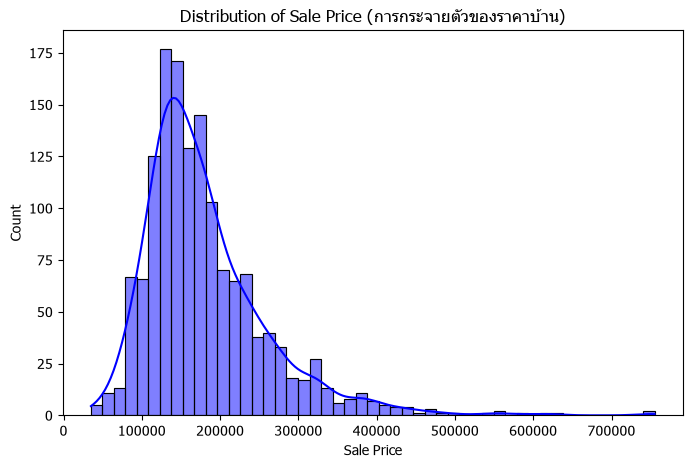

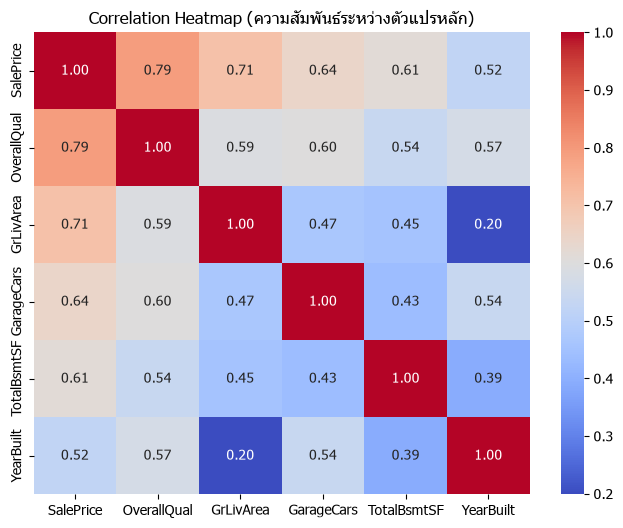

In [26]:
import matplotlib.pyplot as plt

# ตั้งค่าฟอนต์เป็น Tahoma หรือ Leelawadee UI
plt.rcParams['font.family'] = 'Tahoma'

# --- 2.1 Histogram: วาดกราฟแท่งดูการกระจายตัวของราคาบ้าน (SalePrice) ---
plt.figure(figsize=(8, 5))
sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title('Distribution of Sale Price (การกระจายตัวของราคาบ้าน)')
plt.xlabel('Sale Price')
plt.ylabel('Count')
plt.show()

# --- 2.2 Correlation Heatmap: วาดแผนภูมิความร้อนดูความสัมพันธ์ระหว่างตัวแปรตัวเลข ---
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลขและคัดมาเฉพาะบางตัวแปรหลักๆ เพื่อให้ดูง่าย
numeric_cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (ความสัมพันธ์ระหว่างตัวแปรหลัก)')
plt.show()

---

Part 3: Data Cleaning 

In [27]:
# สร้างตัวแปร df_clean ขึ้นมาเพื่อป้องกันไม่ให้กระทบข้อมูลเดิม
df_clean = df.copy()

# --- 3.1 Missing Value Handling: จัดการค่าว่าง ---
# กรณีคอลัมน์ที่มีค่าว่างเป็นตัวเลข เช่น LotFrontage (ระยะทางหน้าบ้านติดถนน) ให้เติมด้วยค่ากลาง (Median)
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())

# กรณีคอลัมน์ข้อความ เช่น Alley (ทางเข้าซอย) ถ้าว่างหมายถึง "ไม่มี" ให้เติมข้อความว่า "None"
df_clean['Alley'] = df_clean['Alley'].fillna('None')

# --- 3.2 Duplicate Removal: ลบข้อมูลซ้ำ (ถ้ามี) ---
df_clean = df_clean.drop_duplicates()

# --- 3.3 Data Type Conversion & Compare Mean/Median: เปรียบเทียบค่าเฉลี่ยกับมัธยฐานของราคาบ้าน ---
mean_price = df_clean['SalePrice'].mean()
median_price = df_clean['SalePrice'].median()

print(f"ค่าเฉลี่ยราคาบ้าน (Mean): {mean_price:,.2f}")
print(f"ค่ามัธยฐานราคาบ้าน (Median): {median_price:,.2f}")

ค่าเฉลี่ยราคาบ้าน (Mean): 180,921.20
ค่ามัธยฐานราคาบ้าน (Median): 163,000.00


---

Part 4: Feature Engineering

In [28]:
# --- 4.1 Label Encoding: แปลงข้อมูลแบบมีลำดับ (เช่น คุณภาพการสร้าง CentralAir ยอมรับ Y/N หรือ MSZoning) ---
# แปลงคอลัมน์ CentralAir (มีแอร์ไหม: Y/N) ให้เป็น 1 และ 0
df_clean['CentralAir_Encoded'] = df_clean['CentralAir'].map({'Y': 1, 'N': 0})

# --- 4.2 One-Hot Encoding: แปลงข้อมูลกลุ่มที่ไม่มีลำดับเป็นคอลัมน์ 0/1 แยกกัน ---
# แปลงคอลัมน์ HouseStyle (สไตล์ของบ้าน)
house_style_encoded = pd.get_dummies(df_clean['HouseStyle'], prefix='Style', dtype=int)

# แสดงตัวอย่างผลลัพธ์การทำ One-Hot Encoding 5 แถวแรก
print("\n--- ตัวอย่างผลลัพธ์ One-Hot Encoding ของคอลัมน์ HouseStyle ---")
print(house_style_encoded.head())


--- ตัวอย่างผลลัพธ์ One-Hot Encoding ของคอลัมน์ HouseStyle ---
   Style_1.5Fin  Style_1.5Unf  Style_1Story  Style_2.5Fin  Style_2.5Unf  \
0             0             0             0             0             0   
1             0             0             1             0             0   
2             0             0             0             0             0   
3             0             0             0             0             0   
4             0             0             0             0             0   

   Style_2Story  Style_SFoyer  Style_SLvl  
0             1             0           0  
1             0             0           0  
2             1             0           0  
3             1             0           0  
4             1             0           0  
